In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib import colors
from matplotlib import font_manager
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define Directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.5.1/'

In [3]:
# Open File
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open Each File
def Files_Open(Model, Diri, Subset):
    Data_DF = Open_File(Diri+Model+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Model+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Model+'_Codes_Output.csv')
# Edit Time Format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create Phase Distribution Bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)
VLT_Bins = Create_Bins(-600,600,50)
B_Bins = Create_Bins(-45,135,7.5)
VUT_Bins = Create_Bins(-600,600,50)
Bins_Bounds = numpy.array([-600,600,50,-45,135,7.5])

In [6]:
# Number of Years For Each Climate Scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Open Files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [8]:
# Create Function to Calculate Phase Space Distribution
def Phase_Space_Distr(DF, VLT_Bins, B_Bins, VUT_Bins, Model):
    VLT_B_Count = numpy.zeros((len(VLT_Bins)-1, len(B_Bins)-1))
    VLT_VUT_Count = numpy.zeros((len(VLT_Bins)-1, len(VUT_Bins)-1))
#
# Define Bins
    Params_VLT = Create_Bins(0,40,10)
    Params_B = Create_Bins(0,5,1.25)
    Params_VUT = Create_Bins(0,40,10)
# Count Phase Space Distribution
    for j in range(len(VLT_Bins)-1):
        for k in range(len(B_Bins)-1):
            VLT_B_Count[j][k] = Phase_Space_Count(DF, "VLT", "B", VLT_Bins[j], VLT_Bins[j+1], \
            B_Bins[k], B_Bins[k+1], Params_VLT, Params_B)
        for l in range(len(VUT_Bins)-1):
            VLT_VUT_Count[j][l] = Phase_Space_Count(DF, "VLT", "VUT", VLT_Bins[j], VLT_Bins[j+1], \
            VUT_Bins[l], VUT_Bins[l+1], Params_VLT, Params_VUT)
#
# Calculate Phase Space Density
    VLT_B_Density = VLT_B_Count / numpy.sum(VLT_B_Count) * 1000
    VLT_VUT_Density = VLT_VUT_Count / numpy.sum(VLT_VUT_Count) * 1000
    return (VLT_B_Density, VLT_VUT_Density)

In [9]:
# Count Phase Space Distribution
def Phase_Space_Count(DF, x_Var, y_Var, x_Min, x_Max, y_Min, y_Max, Params_x, Params_y):
# Create Subset of Datapoints Within Gridbox
    Subset = DF[(DF[x_Var] >= x_Min) & (DF[x_Var] <= x_Max) &
    (DF[y_Var] >= y_Min) & (DF[y_Var] <= y_Max)]
    Count = len(Subset)
    if Count > 0:
        Count_Total = 0
# Apply Smoothing
        for m in range(len(Params_x)):
            for n in range(len(Params_y)):
                Param_x, Param_y = Params_x[m], Params_y[n]
# Count Number of Datapoints Within Gridbox
                Subset = DF[(DF[x_Var] >= x_Min-Param_x) & (DF[x_Var] <= x_Max+Param_x) &
                (DF[y_Var] >= y_Min-Param_y) & (DF[y_Var] <= y_Max+Param_y)]
                Count = len(Subset)
                Count_Total += Count
        Count_Final = Count_Total / (len(Params_x) * len(Params_y))
# If No Datapoints In Gridbox
    else:
        Count_Final = 0
    return (Count_Final)

In [10]:
# Calculate Percentage of Points in Each Quadrant
def Phase_Space_Quadrant(Density_1000, Var):
    Density = Density_1000 / 1000
    x_Length = len(Density)
    y_Length = len(Density[0])
    x_Mid = int(x_Length / 2)
    Right_Half = Density[x_Mid:]
    Left_Half = Density[:x_Mid]
    Q1, Q2, Q3, Q4 = 0, 0, 0, 0
    if Var == "VUT":
        y_Mid = int(y_Length / 2)
    elif Var == "B":
        y_Mid = int(y_Length / 3)
# Sum All Gridboxes Within Quadrant
    for i in range(len(Right_Half)):
        Top_Right = numpy.sum(Right_Half[i][y_Mid:])
        Q1 += Top_Right
        Bottom_Right = numpy.sum(Right_Half[i][:y_Mid])
        Q4 += Bottom_Right
    for j in range(len(Left_Half)):
        Top_Left = numpy.sum(Left_Half[j][y_Mid:])
        Q2 += Top_Left
        Bottom_Left = numpy.sum(Left_Half[j][:y_Mid])
        Q3 += Bottom_Left
    return (numpy.array([Q1, Q2, Q3, Q4]))

In [11]:
# Plot Cyclone Phase Distribution
def Phase_Distr_Plot(DF, Model, i, Bounds, Colours, Colourbar, Subset):
# Use Function to Calculate Distributions
    VLT_B, VLT_VUT = Phase_Space_Distr(DF, VLT_Bins, B_Bins, VUT_Bins, Model)
#
# VLT B Distribution
    Axis = Fig.add_subplot(3,2,i*2+1)
    for j in range(len(VLT_B)):
        for k in range(len(VLT_B[0])):
            Colour = Distr_Colour(VLT_B[j][k], Colours, Bounds)
            pyplot.fill_between([VLT_Bins[j],VLT_Bins[j+1]], B_Bins[k], B_Bins[k+1], color=Colour)
    Phase_Distr_Formatting("B", Model, Axis, Subset)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(VLT_B, "B")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2)
#
# VLT VUT Distribution
    Axis = Fig.add_subplot(3,2,i*2+2)
    for j in range(len(VLT_VUT)):
        for l in range(len(VLT_VUT[0])):
            Colour = Distr_Colour(VLT_VUT[j][l], Colours, Bounds)
            pyplot.fill_between([VLT_Bins[j],VLT_Bins[j+1]], VLT_Bins[l], VLT_Bins[l+1], color=Colour)
    Phase_Distr_Formatting("VUT", Model, Axis, Subset)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(VLT_VUT, "VUT")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2+1)
#
# Colour Bar
    if Colourbar == True:
        Cbar_Label = 'Density (Per 1000 Data Points)'
        C_Map = mcolors.LinearSegmentedColormap.from_list("Density (10^-3)", Colours, N=len(Colours))
        Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='max')
        Cax = Axis.inset_axes([-0.6, -0.085, 1, 0.03], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, \
        label=Cbar_Label, ticks=Bounds, shrink=0.7)

In [12]:
# Formatting For Cyclone Phase Distribution Plot
def Phase_Distr_Formatting(y_Var, Model, Axis, Subset):
    x_Axis = Create_Bins(Bins_Bounds[0],Bins_Bounds[1],100)
    pyplot.xlim(Bins_Bounds[0],Bins_Bounds[1])
    if y_Var == "B":
        y_Axis = Create_Bins(Bins_Bounds[3],Bins_Bounds[4],15)
        pyplot.ylim(Bins_Bounds[3],Bins_Bounds[4])
        pyplot.plot([-1000,1000], [15,15], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-150,300], 'black', linewidth=0.5)
    else:
        y_Axis = Create_Bins(Bins_Bounds[0],Bins_Bounds[1],100)
        pyplot.ylim(Bins_Bounds[0],Bins_Bounds[1])
        pyplot.plot([-1000,1000], [0,0], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-1000,1000], 'black', linewidth=0.5)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    pyplot.xlabel('VLT', fontsize=12)
    pyplot.ylabel(y_Var, fontsize=12)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    if Subset == "":
        pyplot.title(Model, fontsize=20)
    else:
        pyplot.title(str(Model + ' (' + Subset + ')'), fontsize=18)

In [13]:
# Calculate Difference Between Models
def Phase_Space_Diff(DF_1, DF_2, Model_1, Model_2):
    VLT_B_1, VLT_VUT_1 = Phase_Space_Distr(DF_1, VLT_Bins, B_Bins, VUT_Bins, Model_1)
    VLT_B_2, VLT_VUT_2 = Phase_Space_Distr(DF_2, VLT_Bins, B_Bins, VUT_Bins, Model_2)
    VLT_B_Diff = VLT_B_1 - VLT_B_2
    VLT_VUT_Diff = VLT_VUT_1 - VLT_VUT_2
    VLT_B_Quadrant_Percent = Phase_Space_Quadrant(VLT_B_1, "B") - Phase_Space_Quadrant(VLT_B_2, "B")
    VLT_VUT_Quadrant_Percent = Phase_Space_Quadrant(VLT_VUT_1, "VUT") - Phase_Space_Quadrant(VLT_VUT_2, "VUT")
    return (VLT_B_Diff, VLT_VUT_Diff, VLT_B_Quadrant_Percent, VLT_VUT_Quadrant_Percent)

In [14]:
# Plot Cyclone Phase Distribution Difference
def Phase_Diff_Plot(DF_1, DF_2, Model_1, Model_2, i, Bounds, Colours, Colourbar, Subset):
# Use Function to Calculate Distribution Differences
    VLT_B_Diff, VLT_VUT_Diff, VLT_B_Quadrant_Percent, VLT_VUT_Quadrant_Percent = \
    Phase_Space_Diff(DF_1, DF_2, Model_1, Model_2)
#
# VLT B Distribution
    Axis = Fig.add_subplot(3,2,i*2+1)
    for j in range(len(VLT_B_Diff)):
        for k in range(len(VLT_B_Diff[0])):
            Colour = Diff_Colour(VLT_B_Diff[j][k], Colours, Bounds)
            pyplot.fill_between([VLT_Bins[j],VLT_Bins[j+1]], B_Bins[k], B_Bins[k+1], color=Colour)
    Phase_Diff_Formatting("B", Model_1, Model_2, Axis, Subset)
# Add Quadrant Percent
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(VLT_B_Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % VLT_B_Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2)
#
# VLT VUT Distribution
    Axis = Fig.add_subplot(3,2,i*2+2)
    for j in range(len(VLT_VUT_Diff)):
        for l in range(len(VLT_VUT_Diff[0])):
            Colour = Diff_Colour(VLT_VUT_Diff[j][l], Colours, Bounds)
            pyplot.fill_between([VLT_Bins[j],VLT_Bins[j+1]], VLT_Bins[l], VLT_Bins[l+1], color=Colour)
    Phase_Diff_Formatting("VUT", Model_1, Model_2, Axis, Subset)
# Add Quadrant Percent
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(VLT_VUT_Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % VLT_VUT_Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2+1)
#
# Colour Bar
    if Colourbar == True:
        Cbar_Label = 'Density Diff (Per 1000 Data Points)'
        C_Map = mcolors.LinearSegmentedColormap.from_list("Density (10^-3)", Colours, N=len(Colours))
        Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='both')
        Cax = Axis.inset_axes([-0.6, -0.085, 1, 0.03], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, \
        label=Cbar_Label, ticks=Bounds, shrink=0.7)

In [15]:
# Formatting For Cyclone Phase Difference Plot
def Phase_Diff_Formatting(y_Var, Model_1, Model_2, Axis, Subset):
    x_Axis = Create_Bins(Bins_Bounds[0],Bins_Bounds[1],100)
    pyplot.xlim(Bins_Bounds[0],Bins_Bounds[1])
    if y_Var == "B":
        y_Axis = Create_Bins(Bins_Bounds[3],Bins_Bounds[4],15)
        pyplot.ylim(Bins_Bounds[3],Bins_Bounds[4])
        pyplot.plot([-1000,1000], [15,15], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-150,300], 'black', linewidth=0.5)
    else:
        y_Axis = Create_Bins(Bins_Bounds[0],Bins_Bounds[1],100)
        pyplot.ylim(Bins_Bounds[0],Bins_Bounds[1])
        pyplot.plot([-1000,1000], [0,0], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-1000,1000], 'black', linewidth=0.5)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    pyplot.xlabel('VLT', fontsize=12)
    pyplot.ylabel(y_Var, fontsize=12)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    if Subset == "":
        pyplot.title(str(Model_1 + ' - ' + Model_2), fontsize=20)
    else:
        pyplot.title(str(Model_1 + ' - ' + Model_2 + ' (' + Subset + ')'), fontsize=18)

In [16]:
# Define Colours
Distr_Colours = ['lightskyblue', 'deepskyblue', 'lightseagreen', \
'limegreen', 'greenyellow', 'yellow', 'orange', 'red']
Distr_Bounds = numpy.array([0,1,2,5,10,20,30,40])
#
# Create Function For Colours
def Distr_Colour(Density, Colours, Bounds):
    for k in range(len(Colours)):
        if Density == 0:
            Colour = 'white'
        else:
            Bin = numpy.digitize(Density, bins=Bounds[1:], right=True)
            Colour = Colours[Bin]
    return (Colour)

In [17]:
# Define Colours
Diff_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'lawngreen', \
'gold', 'orange', 'darkorange', 'red']
Diff_Bounds = numpy.array([-4,-3,-2,-1,1,2,3,4])
#
# Create Function of Colours of Cyclone Phase Difference Plots
def Diff_Colour(Diff, Colours, Bounds):
    for k in range(len(Colours)):
        if Diff == 0:
            Colour = 'white'
        else:
            Bin = numpy.digitize(Diff, bins=Bounds, right=True)
            Colour = Colours[Bin]
    return (Colour)

In [18]:
# Letter Labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    Axis.text(0.05, 0.96, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':20},color='black')

In [19]:
# Create Subset of Data: Below 1005hPa
Control_1005hPa = Control_Data[Control_Data["SLP(hPa)"] <= 1005].reset_index()
RCP45_1005hPa = RCP45_Data[RCP45_Data["SLP(hPa)"] <= 1005].reset_index()
RCP85_1005hPa = RCP85_Data[RCP85_Data["SLP(hPa)"] <= 1005].reset_index()

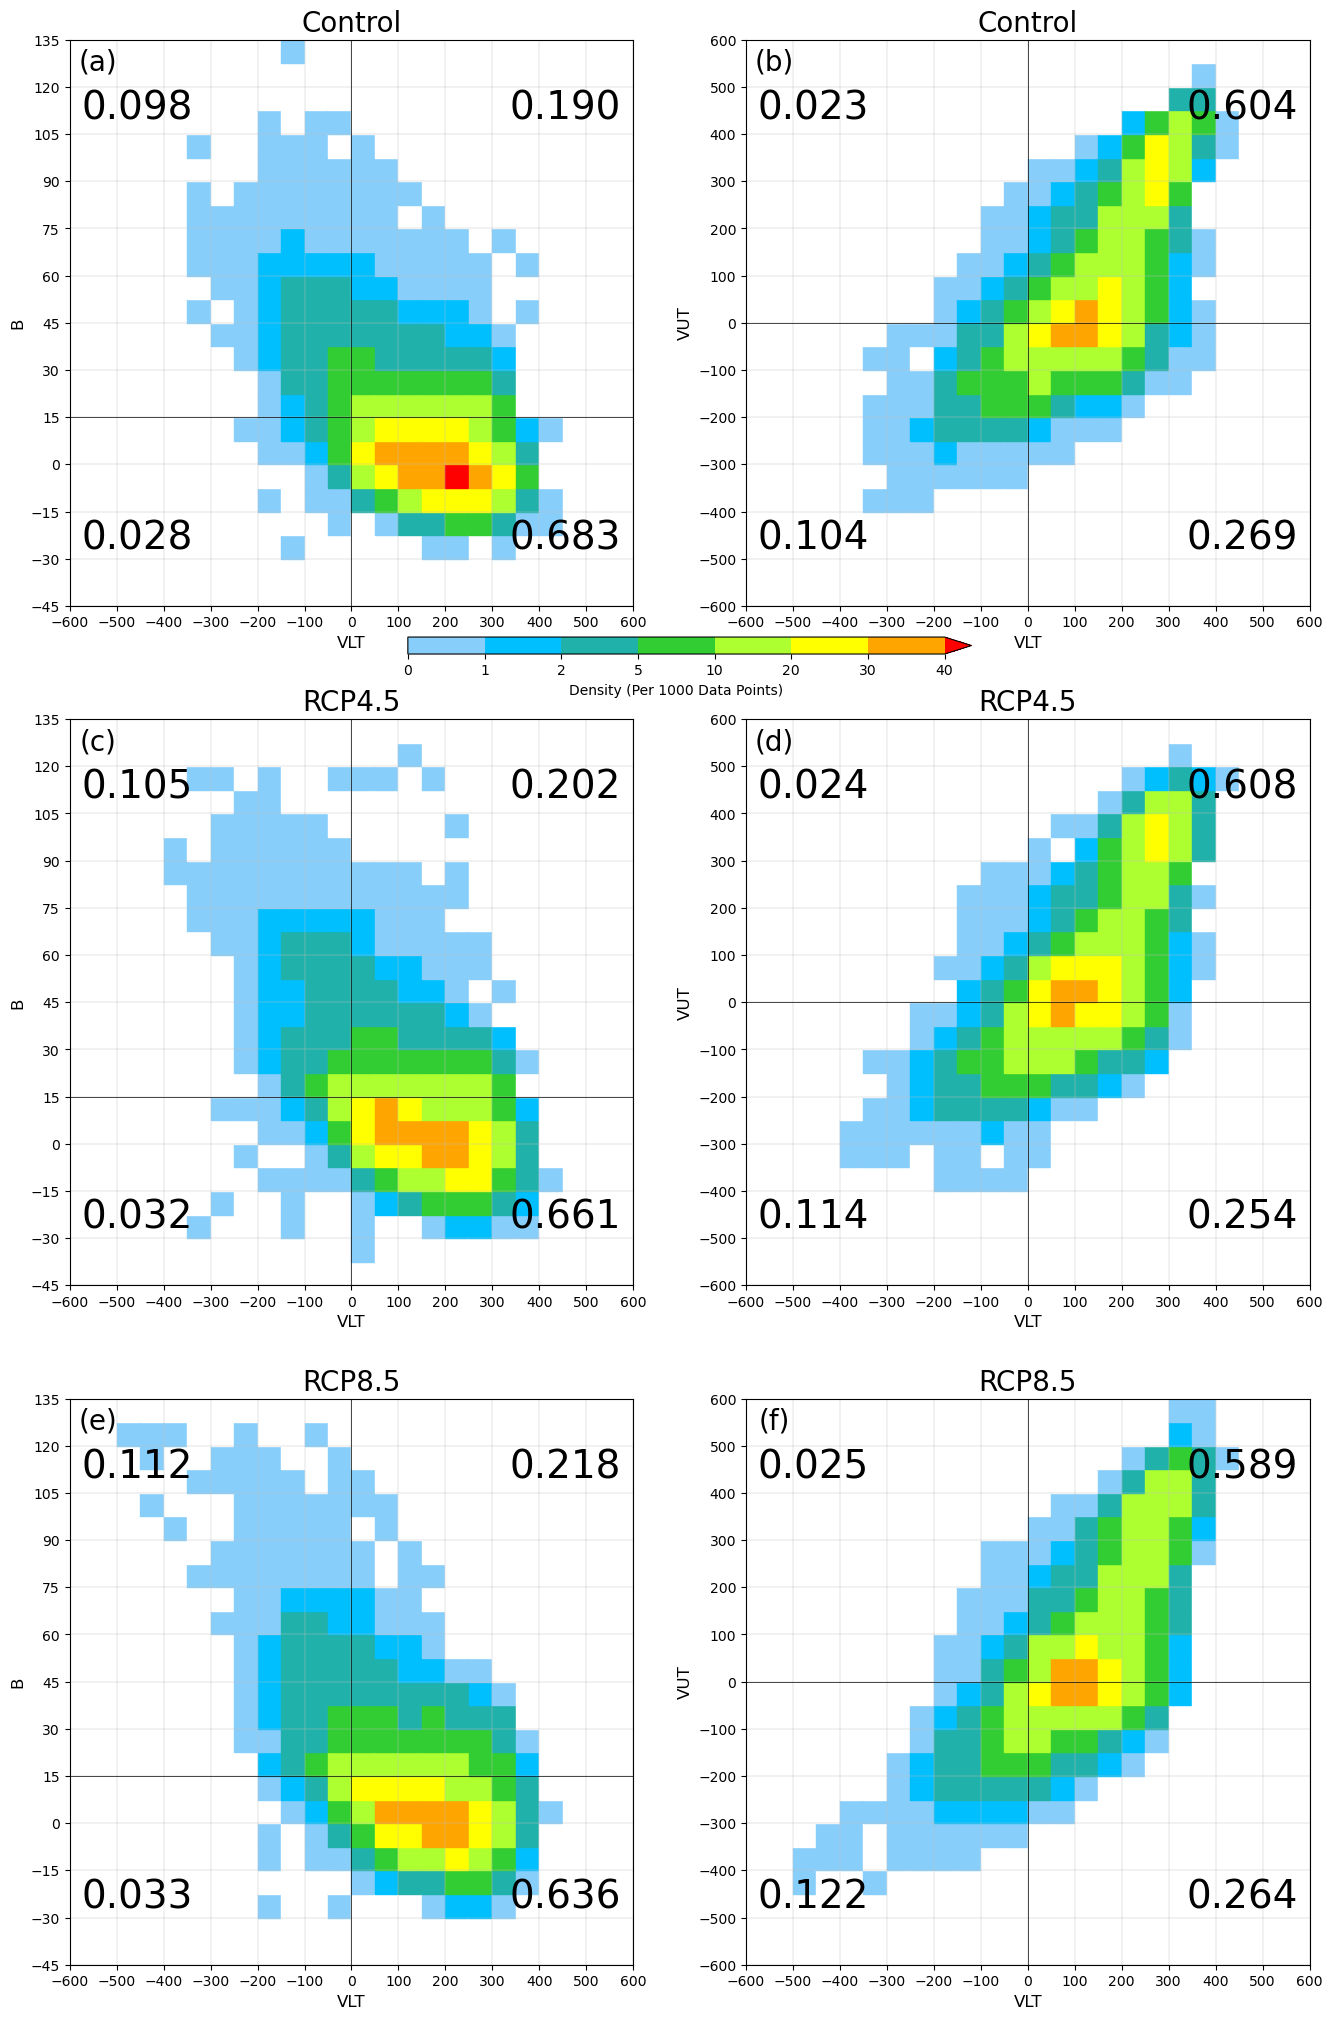

In [20]:
# Figure B10
# Plot Phase Space Distributions
Fig = pyplot.figure(figsize=(16,25))
Phase_Distr_Plot(Control_1005hPa, "Control", 0, Distr_Bounds, Distr_Colours, True, "")
Phase_Distr_Plot(RCP45_1005hPa, "RCP4.5", 1, Distr_Bounds, Distr_Colours, False, "")
Phase_Distr_Plot(RCP85_1005hPa, "RCP8.5", 2, Distr_Bounds, Distr_Colours, False, "")
Fig.savefig(Output_Diri+'Figure_B10.png', bbox_inches='tight')

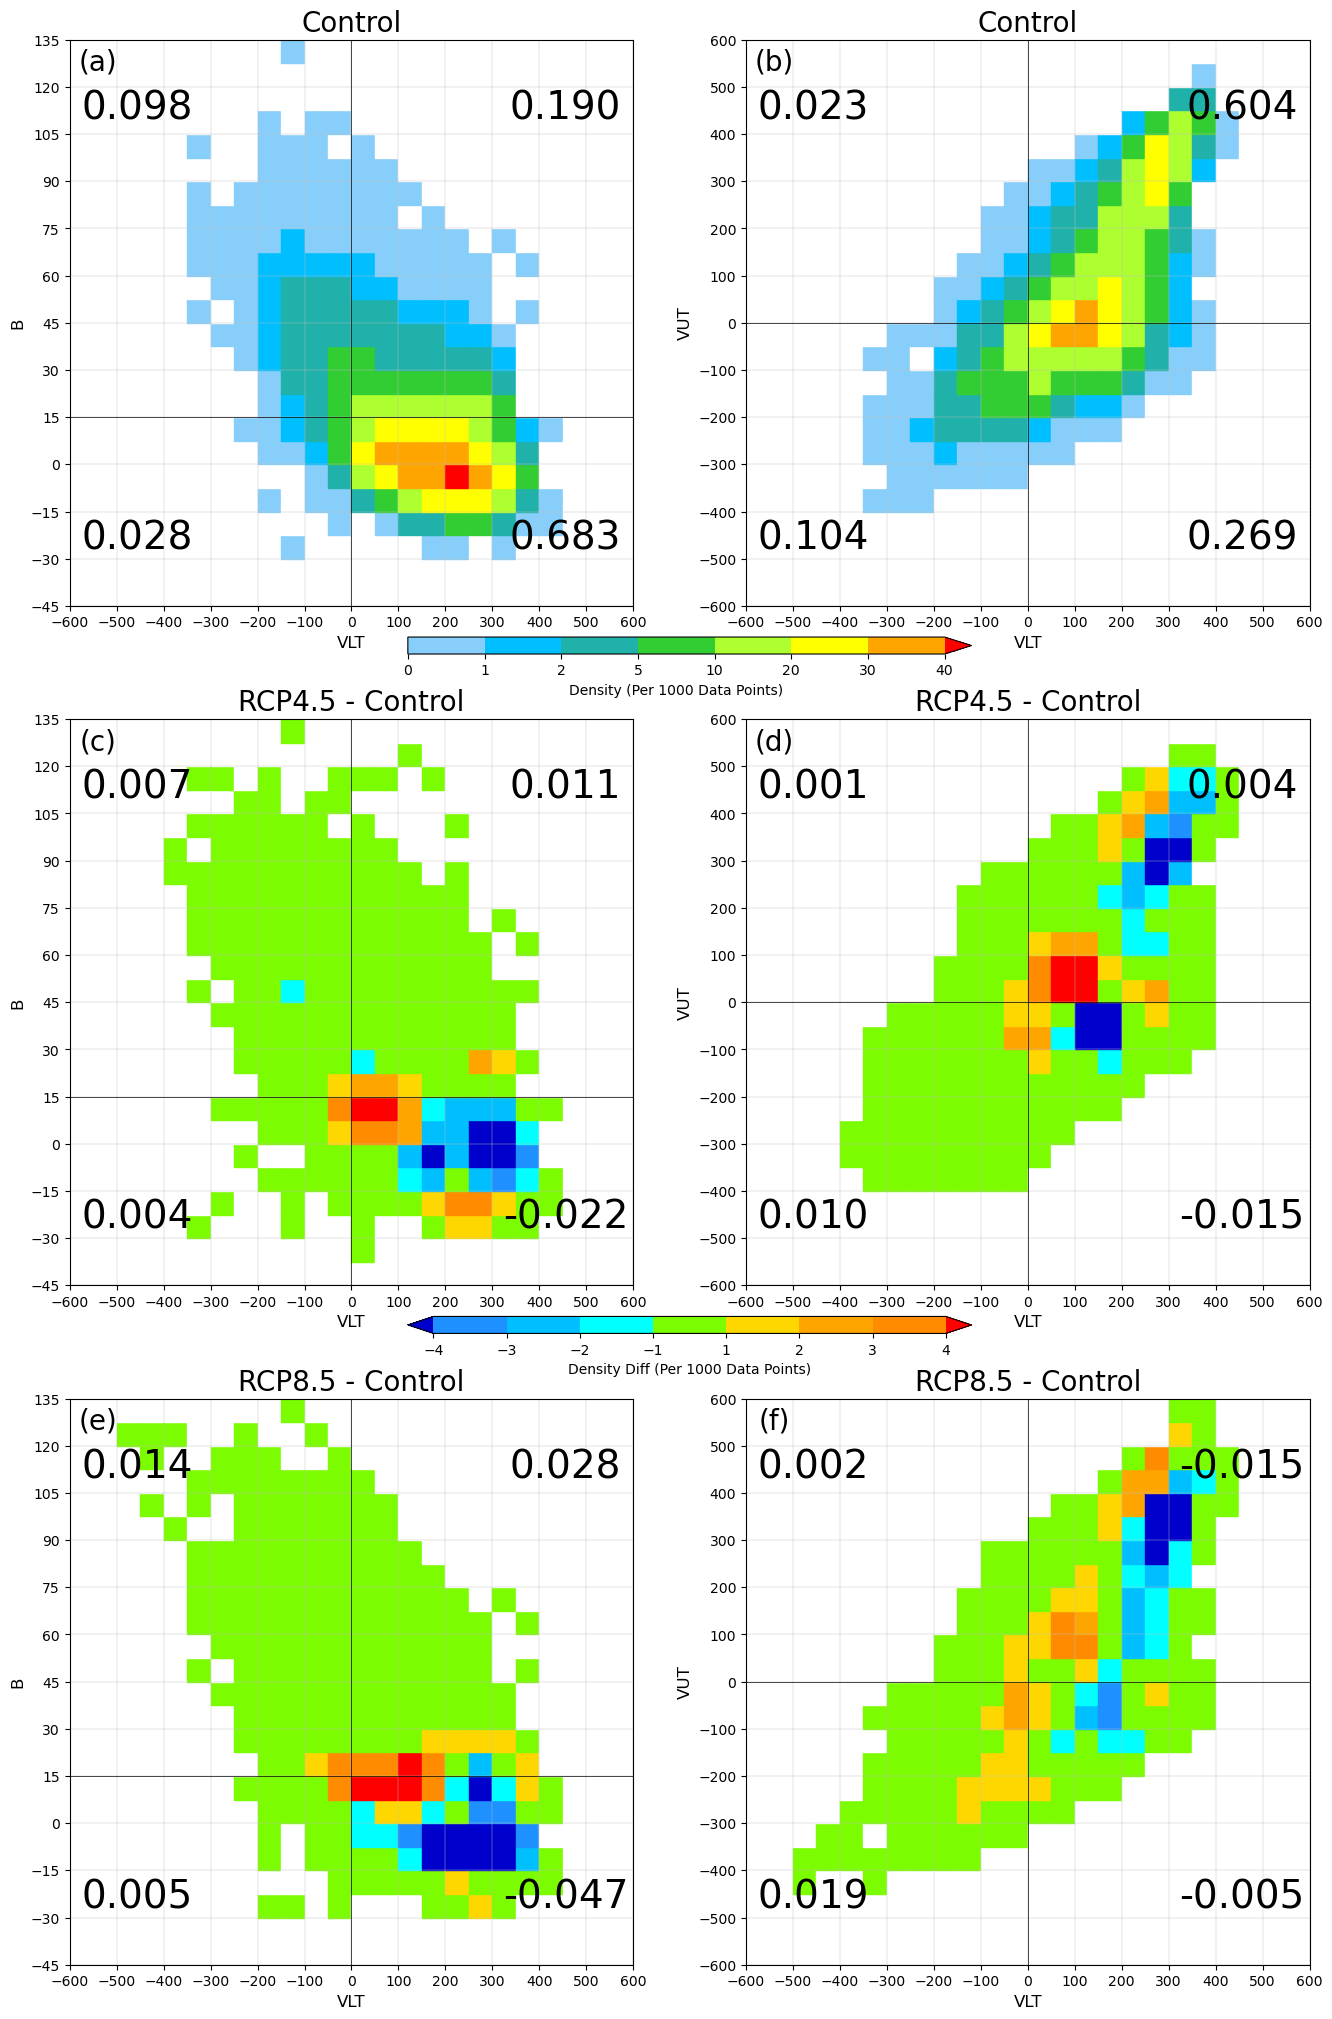

In [21]:
# Figure 10
# Plot Differences Between Phase Space Distributions
Fig = pyplot.figure(figsize=(16,25))
Phase_Distr_Plot(Control_1005hPa, "Control", 0, Distr_Bounds, Distr_Colours, True, "")
Phase_Diff_Plot(RCP45_1005hPa, Control_1005hPa, "RCP4.5", "Control", 1, Diff_Bounds, Diff_Colours, True, "")
Phase_Diff_Plot(RCP85_1005hPa, Control_1005hPa, "RCP8.5", "Control", 2, Diff_Bounds, Diff_Colours, False, "")
Fig.savefig(Output_Diri+'Figure_10.png', bbox_inches='tight')